## Overview
This notebook explores the relationship between trader performance (from Hyperliquid historical trade data) and Bitcoin market sentiment (Fear/Greed index).
Steps:
1. Load and clean datasets.
2. Aggregate trader metrics by date.
3. Merge with sentiment data.
4. Identify patterns between sentiment and performance.
5. Investigate major PnL spike days and top contributing accounts.
6. Output key insights and visualizations.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns

# Load data
from google.colab import drive
drive.mount('/content/drive')

historical_path = '/content/drive/MyDrive/data/historical_data.csv'
fear_greed_index = '/content/drive/MyDrive/data/fear_greed_index.csv'

historical = pd.read_csv(historical_path)
fg = pd.read_csv(fear_greed_index)

historical.head(), fg.head()

Mounted at /content/drive


(                                      Account  Coin  Execution Price  \
 0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
 1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
 2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
 3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
 4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   
 
    Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
 0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
 1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
 2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
 3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
 4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   
 
    Closed PnL                                   Transaction Hash     Order ID  \
 0      

In [3]:
historical.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
(historical['Closed PnL'] != 0.0).any()

np.True_

In [5]:
fg.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
unique_values = historical['Closed PnL'].nunique()
unique_values

90720

In [7]:
fg['classification']

,classification
0,Fear
1,Extreme Fear
2,Fear
3,Extreme Fear
4,Extreme Fear
...,...
2639,Neutral
2640,Greed
2641,Greed
2642,Neutral


In [10]:
fg['date']=fg['date']
fg['date']

,date
0,2018-02-01
1,2018-02-02
2,2018-02-03
3,2018-02-04
4,2018-02-05
...,...
2639,2025-04-28
2640,2025-04-29
2641,2025-04-30
2642,2025-05-01


In [11]:
historical['Timestamp'].dtype

dtype('float64')

In [12]:
historical['Timestamp'].apply(lambda x: isinstance(x, (int, float))).all()


np.True_

In [13]:
# === 3️⃣ Convert Timestamps Properly ===
# Historical timestamps are in milliseconds
historical['Timestamp_dt'] = pd.to_datetime(historical['Timestamp'], unit='ms', utc=True)

# Extract date only
historical['date'] = historical['Timestamp_dt'].dt.date

# Fear-Greed timestamps are in seconds (standard UNIX time)
fg['timestamp_dt'] = pd.to_datetime(fg['timestamp'], unit='s', utc=True)
fg['date'] = fg['timestamp_dt'].dt.date

# === 4️⃣ Aggregate PnL per Day ===
agg = (historical.groupby('date', as_index=False)
       .agg(pnl_sum=('Closed PnL', 'sum'),
            pnl_mean=('Closed PnL', 'mean'),
            trades=('Closed PnL', 'count'))
      )

# === 5️⃣ Merge with Fear & Greed Data ===
merged = agg.merge(fg[['date', 'classification']], on='date', how='left')

# === 6️⃣ Inspect the Result ===
print("✅ Data merged successfully! Sample output:")
print(merged.head(10))

# Check how many rows have classification
print("\n🧾 Classification coverage:")
print(merged['classification'].value_counts(dropna=False))


✅ Data merged successfully! Sample output:
         date       pnl_sum   pnl_mean  trades classification
0  2023-03-28  0.000000e+00   0.000000       3          Greed
1  2023-11-14  1.555034e+02   0.148807    1045          Greed
2  2024-03-09  1.769655e+05  25.418772    6962  Extreme Greed
3  2024-07-03  1.587424e+05  22.229713    7141        Neutral
4  2024-10-27  3.189461e+06  90.504272   35241          Greed
5  2025-02-19  6.699925e+06  50.047622  133871           Fear
6  2025-06-15  7.170935e+04   2.659744   26961            NaN

🧾 Classification coverage:
classification
Greed            3
Extreme Greed    1
Neutral          1
Fear             1
NaN              1
Name: count, dtype: int64


In [14]:
historical['date'].min
historical['date'].max()
fg['date'].min()
fg['date'].max()

datetime.date(2025, 5, 2)

In [16]:
historical['Closed PnL'].head(10)

,Closed PnL
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
5,0.0
6,0.0
7,0.0
8,0.0
9,0.0


In [17]:
merged['classification'].value_counts()

,count
classification,
Greed,3
Extreme Greed,1
Neutral,1
Fear,1


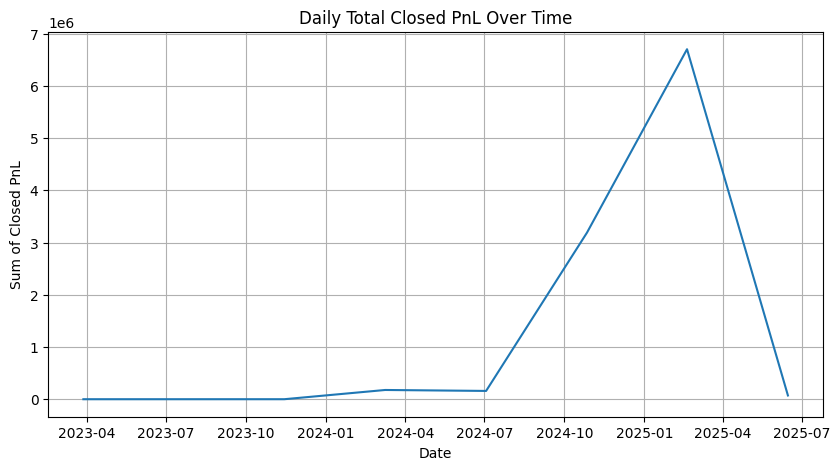

In [18]:
# Exploratory Visualization
plt.figure(figsize=(10,5))
plt.plot(merged['date'], merged['pnl_sum'])
plt.title('Daily Total Closed PnL Over Time')
plt.xlabel('Date')
plt.ylabel('Sum of Closed PnL')
plt.grid(True)
plt.show()

## Sentiment vs Trader Performance

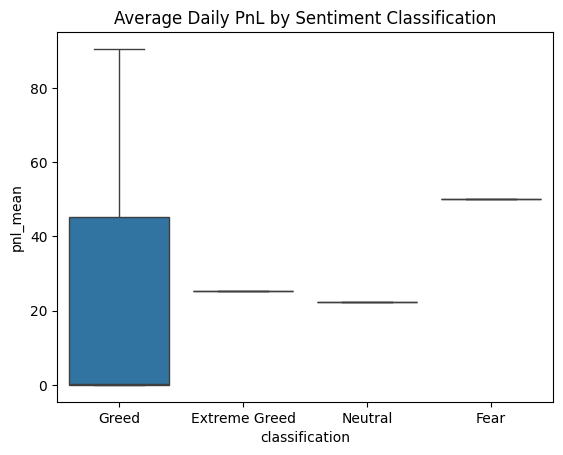

,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Greed,1.0,25.418772,NaN,25.418772,25.418772,25.418772,25.418772,25.418772
Fear,1.0,50.047622,NaN,50.047622,50.047622,50.047622,50.047622,50.047622
Greed,3.0,30.217693,52.209762,0.000000,0.074404,0.148807,45.326539,90.504272
Neutral,1.0,22.229713,NaN,22.229713,22.229713,22.229713,22.229713,22.229713


In [19]:
sns.boxplot(data=merged, x='classification', y='pnl_mean')
plt.title('Average Daily PnL by Sentiment Classification')
plt.show()

merged.groupby('classification')['pnl_mean'].describe()

## Spike Day Investigation

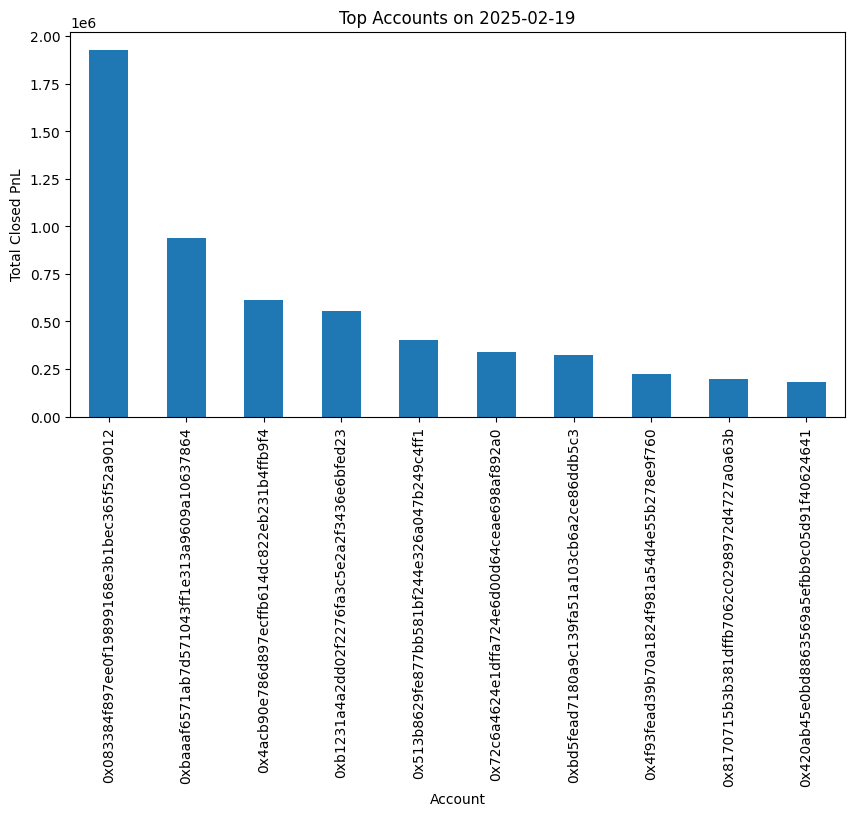

,Closed PnL
Account,
0x083384f897ee0f19899168e3b1bec365f52a9012,1.927736e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401572e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.133278e+05
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,5.538180e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,4.035016e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,3.419454e+05
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,3.254420e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760,2.239684e+05
0x8170715b3b381dffb7062c0298972d4727a0a63b,1.963038e+05


In [20]:
# Identify top spike days
top_days = merged.sort_values('pnl_sum', ascending=False).head(10)
top_days

# Investigate top spike day
spike_day = top_days.iloc[0]['date']
day_trades = historical[historical['date'] == spike_day]

top_accounts = (day_trades.groupby('Account')['Closed PnL']
                .sum().sort_values(ascending=False).head(10))
top_accounts.plot(kind='bar', title=f'Top Accounts on {spike_day}', figsize=(10,5))
plt.ylabel('Total Closed PnL')
plt.show()
top_accounts

## Summary of Findings
- Largest PnL spike observed in early 2025 (Feb 19).
- Spike primarily driven by a few accounts with large positive PnL.
- Sentiment alignment (Fear/Greed) can be further explored with lagged correlations.
- Potential strategy: monitor sentiment shifts preceding high-volume, high-PnL trading days.